[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_8_Pandas_Plot.ipynb)

# 07.8: Quick Plots from pandas: `.plot()` and When to Use It

Every tutorial and Stack Overflow answer about pandas eventually shows something like `df.groupby("pclass")["survived"].mean().plot(kind="bar")`. You have the tools to read that line now, but you might wonder where `.plot()` fits in relation to seaborn.

This notebook answers that question. pandas has its own plotting interface that calls matplotlib directly, with no seaborn involved. It is less capable than seaborn, but it is convenient for one specific pattern: plotting the result of a `groupby`, `pivot_table`, or `value_counts` without any reshaping. In those cases, a single chained call gets the job done.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## `.plot()` on a Series

Every pandas Series has a `.plot()` method. The `kind=` argument picks the chart type. The most useful options are `"hist"`, `"kde"`, `"box"`, and `"bar"`. The result is a matplotlib `Axes`, just like an axes-level seaborn call.

Text(0.5, 0, 'Age')

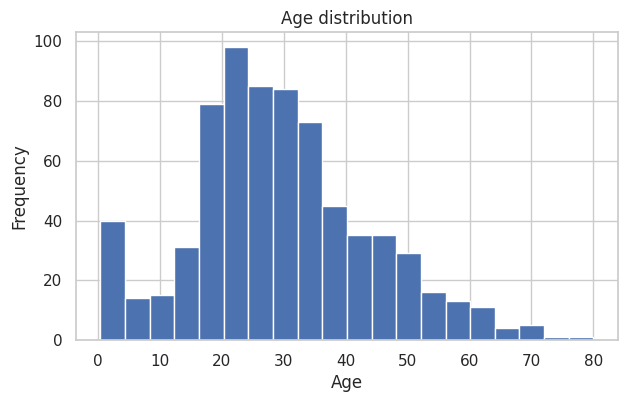

In [2]:
ax = df["age"].plot(kind="hist", bins=20, figsize=(7, 4))
ax.set_title("Age distribution")
ax.set_xlabel("Age")

The output is a plain matplotlib histogram. There is no `data=` argument; pandas already knows which data to use because the method is called directly on the Series. The `figsize=` argument works here because pandas creates its own figure.

You can chain `.plot()` directly off any Series expression.

Text(0.5, 0, 'Fare (pounds)')

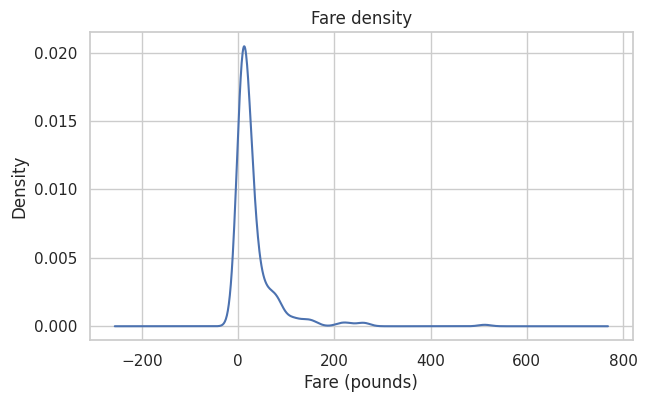

In [3]:
ax = df["fare"].plot(kind="kde", figsize=(7, 4))
ax.set_title("Fare density")
ax.set_xlabel("Fare (pounds)")

## The pattern where pandas shines: groupby then plot

Where `.plot()` earns its place is at the end of a chain that starts with `groupby()`, `value_counts()`, or `pivot_table()`. The aggregation produces a Series or DataFrame with a meaningful index, and `.plot()` turns that index directly into the x-axis without any reshaping.

You already know how to compute survival rate by class.

(0.0, 0.7)

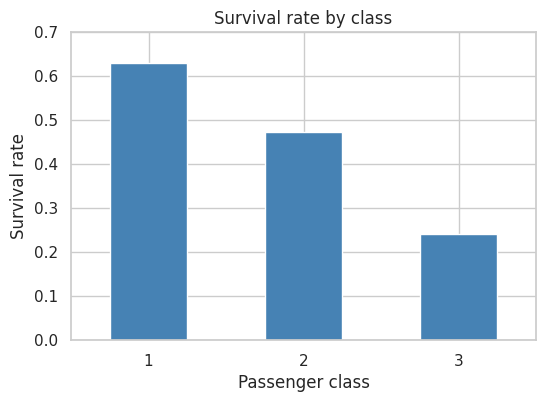

In [4]:
ax = (
    df.groupby("pclass")["survived"]
    .mean()
    .plot(kind="bar", figsize=(6, 4), color="steelblue", rot=0)
)
ax.set_title("Survival rate by class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 0.7)

The `groupby` returns a Series whose index is `[1, 2, 3]`. `.plot(kind="bar")` puts that index on the x-axis and the values on the y-axis. No `x=` or `y=` argument is needed. `rot=0` keeps the tick labels horizontal.

The seaborn equivalent would be `sns.barplot(data=df, x="pclass", y="survived", estimator="mean", errorbar=None)`. Both produce the same bars. The pandas version is shorter but shows no confidence interval; the seaborn version requires you to specify `data=`, `x=`, `y=`, and `estimator=`.

The pattern extends to two-level groupbys.

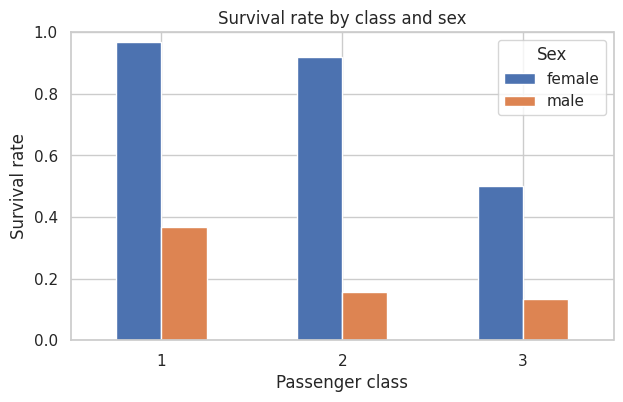

In [5]:
ax = (
    df.groupby(["pclass", "sex"])["survived"]
    .mean()
    .unstack("sex")
    .plot(kind="bar", figsize=(7, 4), rot=0)
)
ax.set_title("Survival rate by class and sex")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.legend(title="Sex")

The two-level groupby produces a Series with a MultiIndex `(pclass, sex)`. `.unstack("sex")` pivots the sex level into columns, giving a DataFrame with `pclass` as the index and one column per sex value. `.plot(kind="bar")` on a DataFrame draws one group of bars per row and one bar color per column.

This is the same result as `sns.barplot(data=df, x="pclass", y="survived", hue="sex")`. Both charts show the same pattern. The pandas version requires a `.unstack()` that is not obvious at first; the seaborn version handles the grouping internally using `hue=`.

## `value_counts().plot()` for categorical counts

Text(0, 0.5, 'Count')

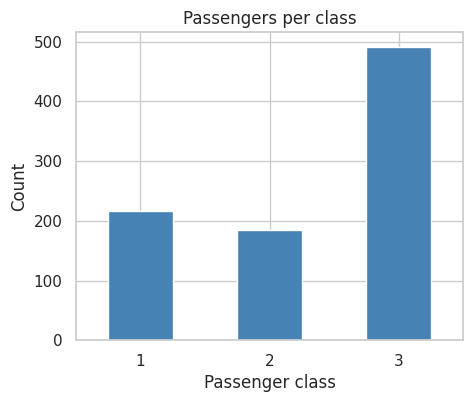

In [6]:
ax = (
    df["pclass"]
    .value_counts()
    .sort_index()
    .plot(kind="bar", figsize=(5, 4), rot=0, color="steelblue")
)
ax.set_title("Passengers per class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Count")

`value_counts()` returns a Series sorted by count descending. `.sort_index()` re-sorts it by the class number so the bars appear in order. This is the pandas equivalent of `sns.countplot(data=df, x="pclass", order=[1, 2, 3])`.

Both work. The pandas version chains naturally off a `value_counts()` call you might already have in your analysis.

## Scatter from a DataFrame

Text(0, 0.5, 'Fare (pounds)')

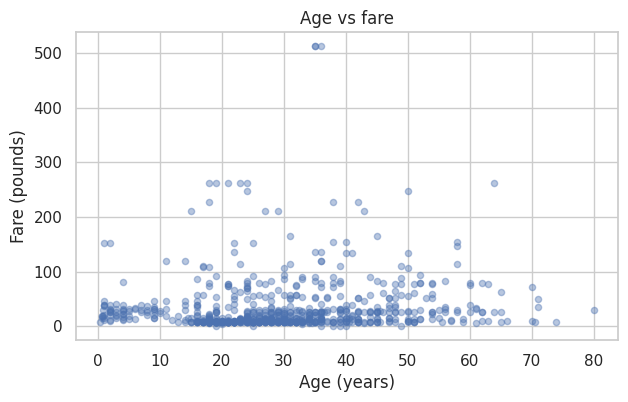

In [7]:
ax = df.plot(
    kind="scatter",
    x="age", y="fare",
    alpha=0.4,
    figsize=(7, 4)
)
ax.set_title("Age vs fare")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare (pounds)")

For a scatter plot, you have to name the `x=` and `y=` columns explicitly because a DataFrame has many columns and pandas does not know which two you want. The result is exactly the same as `sns.scatterplot(data=df, x="age", y="fare", alpha=0.4)` with no seaborn theming.

Notice the plain white background and default matplotlib styling. The `sns.set_theme()` call at the top of this notebook applied to the seaborn charts above but not to this pandas plot, which bypasses seaborn entirely and goes straight to matplotlib's defaults.

## Mixing pandas and seaborn on the same Axes

Because both pandas and seaborn produce matplotlib Axes objects, they can draw on the same Axes. Pass `ax=` to the pandas call and pass the same `ax` to the seaborn call. This is useful when you want to combine things that each library does well.

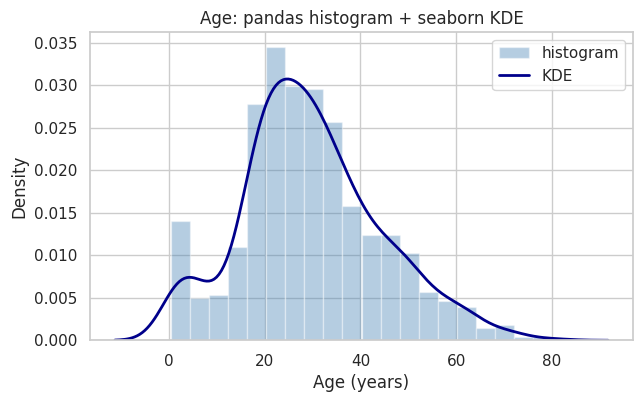

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

df["age"].dropna().plot(kind="hist", bins=20, density=True, alpha=0.4,
                        color="steelblue", label="histogram", ax=ax)

sns.kdeplot(data=df, x="age", ax=ax, color="darkblue", linewidth=2, label="KDE")

ax.set_title("Age: pandas histogram + seaborn KDE")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.legend()

The histogram came from pandas; the KDE curve came from seaborn. Both used the same `ax`. The `density=True` argument in the pandas histogram normalizes the bars to density (total area = 1) so they are on the same scale as the KDE curve. This kind of combination is straightforward because both libraries ultimately speak to matplotlib.

The `label=` arguments allow both items to appear together in a single legend.

## When to use pandas `.plot()` vs seaborn

**Use pandas `.plot()` when:**
- You already have a Series or DataFrame in the right shape from a `groupby`, `pivot_table`, or `value_counts` and want a quick look without any reshaping.
- You are doing exploratory work in a notebook and want the fastest possible one-liner.
- You do not need `hue=`, `col=`, confidence intervals, or statistical overlays.

**Use seaborn when:**
- You need `hue=`, `col=`, or `row=` to encode additional variables.
- You want statistical features: confidence intervals on bars, regression lines, KDE overlays, or distribution comparisons.
- You are making a chart for presentation or a report, where palette control and consistent theming matter.
- You are starting from a tidy (long-format) DataFrame and want seaborn to handle the grouping automatically.

In practice, most analysis notebooks use seaborn for finished charts and occasionally use pandas `.plot()` for quick intermediate checks. Both read from the same DataFrames and both return matplotlib Axes, so mixing them is fine.

## What's next

In 07.9 you will apply everything from this module to a set of exercises using the Titanic dataset. Each exercise asks a question and leaves the choice of chart type to you.